In [239]:
import nltk
import numpy as np
import random
from nltk.corpus import twitter_samples  # sample Twitter dataset from NLTK
from nltk.tokenize import RegexpTokenizer 
from nltk.stem.porter import PorterStemmer  
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# nltk.download('stopwords')
# nltk.download('twitter_samples')

# select the set of positive and negative tweets 
all_positive_tweets=twitter_samples.strings('positive_tweets.json') 
all_negative_tweets=twitter_samples.strings('negative_tweets.json') 

In [269]:
all_positive_tweets = [tweet for tweet in all_positive_tweets if len(tweet.split()) >= 10]
all_negative_tweets = [tweet for tweet in all_negative_tweets if len(tweet.split()) >= 10]

tokenizer=RegexpTokenizer(r'\w+')  
en_stopwords=set(stopwords.words('english'))  
ps=PorterStemmer()  

def removeUsername(text):
    return ' '.join(np.array(text.split(' ')[1:]))

def getCleanedText(text):  
  texttext=text.lower()  
  #tokenize  
  tokens=tokenizer.tokenize(text)  
  new_tokens=[token for token in tokens if token not in en_stopwords]  
  stemmed_tokens=[ps.stem(tokens) for tokens in new_tokens]  
  clean_text=" ".join(stemmed_tokens)  
  return clean_text

In [271]:
Positive_tweets = [removeUsername(p) for p in all_positive_tweets]
Negative_tweets = [removeUsername(n) for n in all_negative_tweets]

Positive_tweets = [getCleanedText(p) for p in Positive_tweets]
Negative_tweets = [getCleanedText(n) for n in Negative_tweets]


holmesjsamuel sure could warmup morn come 15th bath xx
@OJBJ @holmesjsamuel surely this could be your warmup this morning ??? Coming on 15th to Bath :) xx


In [275]:
Positive_tweets_train = np.array(Positive_tweets[:2338])
Positive_tweets_test = np.array(Positive_tweets[2338:])

Negative_tweets_train = np.array(Negative_tweets[:2039])
Negative_tweets_test = np.array(Negative_tweets[2039:])

Training_set = np.concatenate((Positive_tweets_train, Negative_tweets_train))
Testing_set = np.concatenate((Positive_tweets_test, Negative_tweets_test))



In [277]:
#Generate a list of labels for both sets
Training_labels = np.concatenate((np.ones(len(Positive_tweets_train), dtype=int),
                                np.zeros(len(Negative_tweets_train), dtype=int)))
Testing_labels = np.concatenate((np.ones(len(Positive_tweets_test), dtype=int),
                                np.zeros(len(Negative_tweets_test), dtype=int)))

#Asigning the label and shuffling the list
Training_combined = list(zip(Training_set, Training_labels))
random.shuffle(Training_combined)
Training_set[:], Training_labels[:] = zip(*Training_combined) #splitting the tweets from the labels

Testing_combined = list(zip(Testing_set, Testing_labels))
random.shuffle(Testing_combined)
Testing_set[:], Testing_labels[:] = zip(*Testing_combined) #splitting the tweets from the labels


In [279]:
from sklearn.feature_extraction.text import TfidfVectorizer
cv = TfidfVectorizer(ngram_range=(1,2))


Training_vect=cv.fit_transform(Training_set).toarray()  
Testing_vect=cv.transform(Testing_set).toarray()

In [280]:
mlb=MultinomialNB()  
mlb.fit(Training_vect,Training_labels)
Predictions=mlb.predict(Testing_vect)  

In [282]:
right = 0
total = len(Predictions)

for i in range(total):
    if Predictions[i] == Testing_labels[i]:
        right += 1

accuracy = right / total
print("Accuracy:", accuracy)
right

Accuracy: 0.702


702

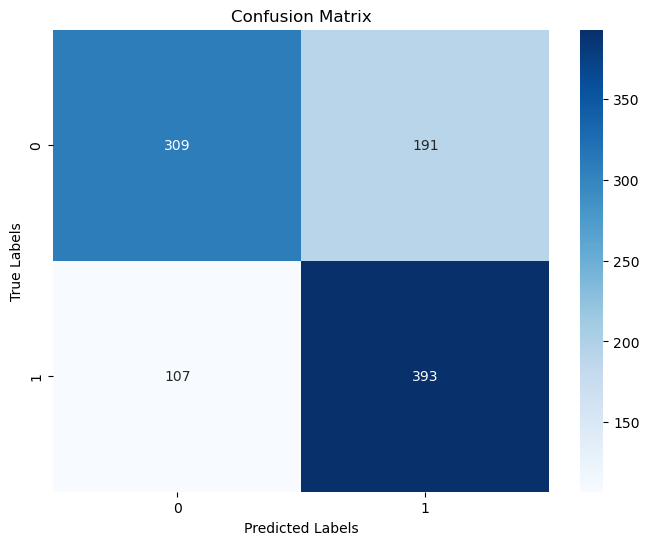

In [285]:
cm = confusion_matrix(Testing_labels, Predictions)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=True, yticklabels=True)

# Add labels and title
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Show the plot
plt.show()

In [287]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(solver='liblinear')
lr.fit(Training_vect,Training_labels) # fit the model
preds = lr.predict(Testing_vect) # make predictions

right = 0
total = len(preds)

for i in range(total):
    if preds[i] == Testing_labels[i]:
        right += 1

accuracy = right / total
print("Accuracy:", accuracy)
right

Accuracy: 0.715


715

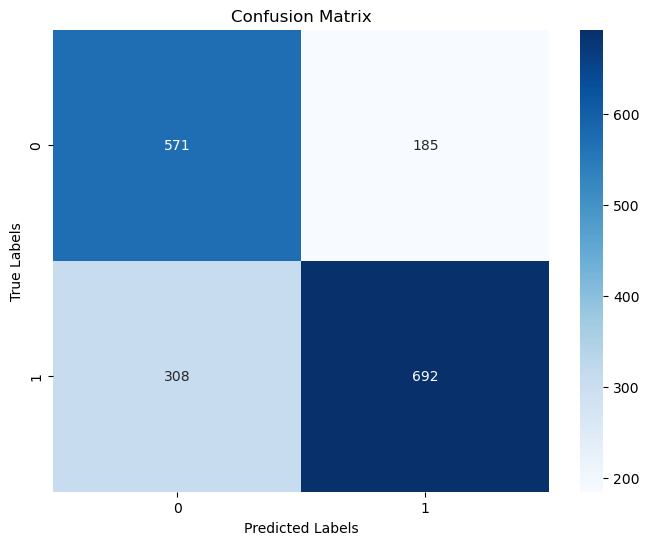

In [259]:
cm = confusion_matrix(Testing_labels, preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=True, yticklabels=True)

# Add labels and title
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Show the plot
plt.show()

In [261]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

svm_model = SVC(kernel='linear')
svm_model.fit(Training_vect, Training_labels)
svm_predictions = svm_model.predict(Testing_vect)



accuracy = accuracy_score(Testing_labels, svm_predictions)
conf_matrix = confusion_matrix(Testing_labels, svm_predictions)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)

Accuracy: 0.7146924829157175
Confusion Matrix:
 [[551 205]
 [296 704]]


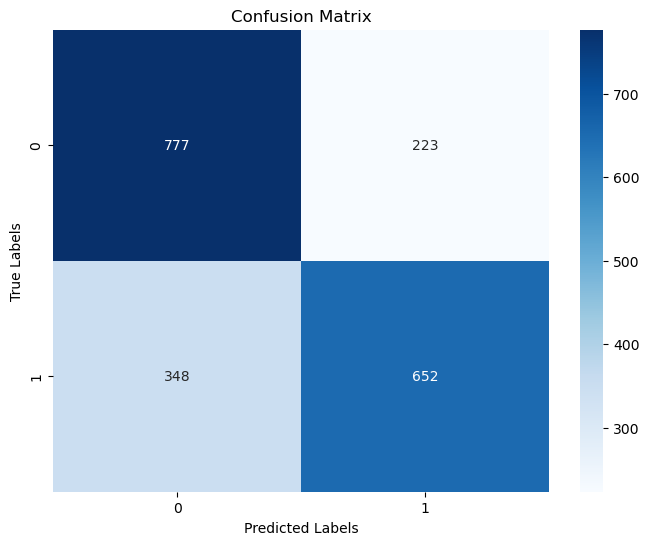

In [107]:
cm = confusion_matrix(Testing_labels, svm_predictions)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=True, yticklabels=True)

# Add labels and title
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Show the plot
plt.show()

In [293]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score

model = Sequential()
model.add(Dense(8, activation='relu', input_shape=(Training_vect.shape[1],)))
model.add(Dropout(0.5))

model.add(Dense(4, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
model.fit(Training_vect, Training_labels, epochs=8, batch_size=16, validation_split=0.1)

y_pred = (model.predict(Testing_vect, batch_size=32) > 0.5).astype("int32")

accuracy = accuracy_score(Testing_labels, y_pred)
print("Accuracy:", accuracy)


D:\Anaconda\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/8
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5363 - loss: 0.6903 - val_accuracy: 0.5982 - val_loss: 0.6747
Epoch 2/8
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6051 - loss: 0.6610 - val_accuracy: 0.6986 - val_loss: 0.6229
Epoch 3/8
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7055 - loss: 0.5663 - val_accuracy: 0.7237 - val_loss: 0.5620
Epoch 4/8
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7641 - loss: 0.4577 - val_accuracy: 0.7283 - val_loss: 0.5314
Epoch 5/8
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7977 - loss: 0.3798 - val_accuracy: 0.7260 - val_loss: 0.5089
Epoch 6/8
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8222 - loss: 0.3322 - val_accuracy: 0.7329 - val_loss: 0.5001
Epoch 7/8
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8187 - loss: 0.3144 - val_accuracy: 0.7420 - val_loss: 0.4960
Epoch 8/8
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8301 - loss: 0.2774 - val_accuracy: 0.7443 - v

In [295]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(Training_vect, Training_labels)

rf_pred = rf_model.predict(Testing_vect)


print("Random Forest Accuracy:", accuracy_score(Testing_labels, rf_pred))


Random Forest Accuracy: 0.696


In [ ]:
print("\nRandom Forest Report:")
print(classification_report(Testing_labels, rf_pred))